In [1]:
import pandas as pd
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [2]:
def summarize_hyperparam(env, mu_type, alg_names):
    def summ_ep(df):
        delta = df.delta.mean()
        delta_obs = df.delta_obs.mean()
        rew = df.sort_values("t")["resource"].values[-1]
        accept_g0 = df[df.group_id == 0].action.mean()
        accept_g1 = df[df.group_id == 1].action.mean()
        return pd.Series(
            {
                "delta": delta,
                "delta_obs": delta_obs,
                "reward": rew,
                "accept_g0": accept_g0,
                "accept_g1": accept_g1,
            }
        )

    files = [f"experiments/{env}/{mu_type}/{alg}/eval/eval_data.csv" for alg in alg_names]
    results = []
    for file in files:
        try:
            alg = file.split("/")[-3]
            df = pd.read_csv(file)
            df = df.groupby("ep").apply(summ_ep).aggregate(["mean", "std"])
            alg_simplified = alg.replace("sellf_hard", "sellf").split("_")[0]
            results.append(
                {
                    "alg": alg,
                    "alg_simplified": alg_simplified,
                    "delta": df["delta"]["mean"],
                    "delta_std": df["delta"]["std"],
                    "delta_obs": df["delta_obs"]["mean"],
                    "delta_obs_std": df["delta_obs"]["std"],
                    "reward": df["reward"]["mean"],
                    "reward_std": df["reward"]["std"],
                    "accept_g0": df["accept_g0"]["mean"],
                    "accept_g1": df["accept_g1"]["mean"],
                }
            )
        except:
            continue
    results = pd.DataFrame(results)
    return results

# FICO with TPR

In [4]:
env_name = "fico_equal"
mu_type = "tpr"

## Ablation

/tmp/ipykernel_2807776/3038078838.py:65: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[2].set_xticklabels(


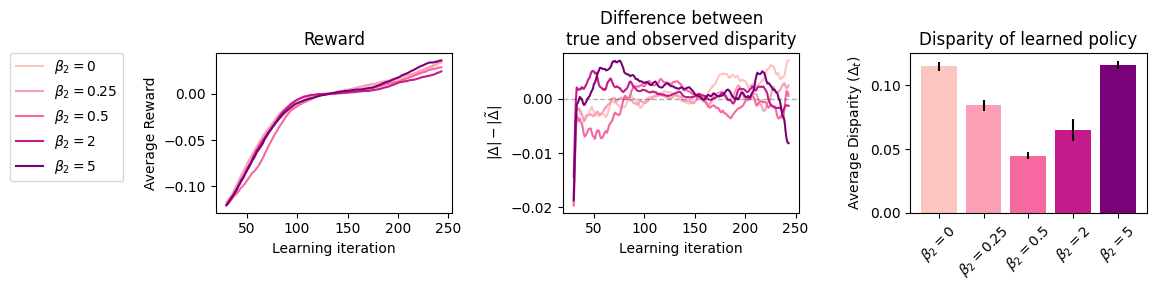

In [78]:
selected_algs = [
    "sellf_hard_beta_1=5 beta_2=0",
    "sellf_hard_beta_1=5 beta_2=0.25",
    "sellf_hard_beta_1=5 beta_2=0.5",
    "sellf_hard_beta_1=5 beta_2=2",
    "sellf_hard_beta_1=5 beta_2=5",
]

def legend_func(alg_name):
    alg_name = alg_name.replace("sellf_hard_", "")
    alg_name = alg_name.replace("beta_1=", "$\\beta_1=$")
    alg_name = alg_name.replace(" beta_2=", ", $\\beta_2=$")
    return alg_name.split(" ")[1]


def color_func(alg_name):
    colors = ['#feebe2','#fbb4b9','#f768a1','#c51b8a','#7a0177']
    idx = selected_algs.index(alg_name)
    return colors[idx]

# first, get average delta of each algorithm
algs_deltas = {}
df_list = [pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv") for alg in selected_algs]
for i in range(len(df_list)):
    df_list[i] = (
        df_list[i]
        .groupby("t")
        .agg(
            {
                "delta": "mean"
            }
        )
    ).agg(["mean", "std"])
    algs_deltas[selected_algs[i]] = {
        "mean": df_list[i]["delta"]["mean"],
        "std": df_list[i]["delta"]["std"]
    }


df_list = [pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/models/progress.csv") for alg in selected_algs]
colors = ['#fcc5c0','#fa9fb5','#f768a1','#c51b8a','#7a0177']

fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3))


window_size = 30
for i in range(5):
    # make color be sequential
    reward = df_list[i]["train/reward"]
    reward = reward.rolling(window=window_size).mean()
    axs[0].plot(reward, color=colors[i])

    difference = (df_list[i]["train/delta"] - df_list[i]["train/delta_obs"])
    difference = difference.rolling(window=window_size).mean()
    axs[1].plot(difference, color=colors[i])


# bar plot of the average delta of each algorithm
axs[2].bar(
    [legend_func(alg) for alg in selected_algs],
    [algs_deltas[alg]["mean"] for alg in selected_algs],
    yerr=[algs_deltas[alg]["std"] for alg in selected_algs],
    color=colors,
)   
axs[2].set_xticklabels(
    [legend_func(alg)for alg in selected_algs],
    rotation=45,
)

#axs[1].set_ylim(-0.01, 0.01)
axs[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha = 0.3)
for i in range(2):
    axs[i].set_xlabel("Learning iteration")
axs[0].set_ylabel("Average Reward")
axs[0].set_title("Reward")
axs[1].set_title("Difference between\ntrue and observed disparity")
axs[1].set_ylabel("$|\Delta| - |\\tilde \Delta |$")
axs[2].set_title("Disparity of learned policy")
axs[2].set_ylabel("Average Disparity ($\Delta_t$)")

# add legend to the first plot
axs[0].legend(
    [legend_func(alg) for alg in selected_algs],
    loc="center left",
    bbox_to_anchor=(-0.9, 0.6)
)
plt.tight_layout()
plt.savefig("figures/ablation.pdf", bbox_inches='tight')

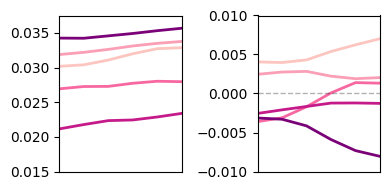

In [77]:
selected_algs = [
    "sellf_hard_beta_1=5 beta_2=0",
    "sellf_hard_beta_1=5 beta_2=0.25",
    "sellf_hard_beta_1=5 beta_2=0.5",
    "sellf_hard_beta_1=5 beta_2=2",
    "sellf_hard_beta_1=5 beta_2=5",
]
df_list = [pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/models/progress.csv") for alg in selected_algs]
colors = ['#fcc5c0','#fa9fb5','#f768a1','#c51b8a','#7a0177']

fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (4, 2))


window_size = 30
for i in range(5):
    # make color be sequential
    reward = df_list[i]["train/reward"]
    reward = reward.rolling(window=window_size).mean()
    axs[0].plot(reward, color=colors[i], lw = 2)

    difference = df_list[i]["train/delta"] - df_list[i]["train/delta_obs"]
    difference = difference.rolling(window=window_size).mean()
    axs[1].plot(difference, color=colors[i], lw = 2)

axs[1].set_ylim(-0.01, 0.01)
axs[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha = 0.3)

for i in range(2):
    axs[i].set_xlim(237, 242)
    axs[i].set_xticks([])

axs[0].set_ylim(0.015, 0.0375)

plt.tight_layout()
plt.savefig("figures/ablation_zoomed.pdf", bbox_inches='tight')

## Comparative Evaluation

In [12]:
alg_names = ["ppo_"]
for beta in [0.5, 1, 2, 5]:
    alg_names.append(f"sellf_hard_beta_1={beta} beta_2={beta}")
    alg_names.append(f"pocar_beta_1={beta} beta_2={beta}")
alg_names = ["ppo_"]
results = summarize_hyperparam(env_name, mu_type, alg_names)
results.sort_values("delta").groupby("alg_simplified").first()

,alg,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1
alg_simplified,,,,,,,,,
ppo,ppo_,0.136096,0.003452,0.136096,0.003452,2372.5,20.156333,0.32781,0.551864


In [13]:
selected_algs = (
    results.sort_values("delta").groupby("alg_simplified").first()["alg"].tolist()
)
df_list = [
    pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv")
    for alg in selected_algs
]
for i in range(len(df_list)):
    # create column with number of acceptions for each group
    df_list[i]["accept_g0"] = df_list[i]["action"] * (df_list[i]["group_id"] == 0)
    df_list[i]["accept_g1"] = df_list[i]["action"] * (df_list[i]["group_id"] == 1)
    
    # for each ep, compute cumulative sum of accept_g0 and accept_g1
    df_list[i]["n_accept_g0"] = df_list[i].groupby("ep")["accept_g0"].cumsum()
    df_list[i]["n_accept_g1"] = df_list[i].groupby("ep")["accept_g1"].cumsum()

    df_list[i] = (
        df_list[i]
        .groupby("t")
        .agg(
            {
                "resource": ["mean", "std"],
                "delta": ["mean", "std"],
                "n_accept_g0": ["mean", "std"],
                "n_accept_g1": ["mean", "std"],
            }
        )
    )

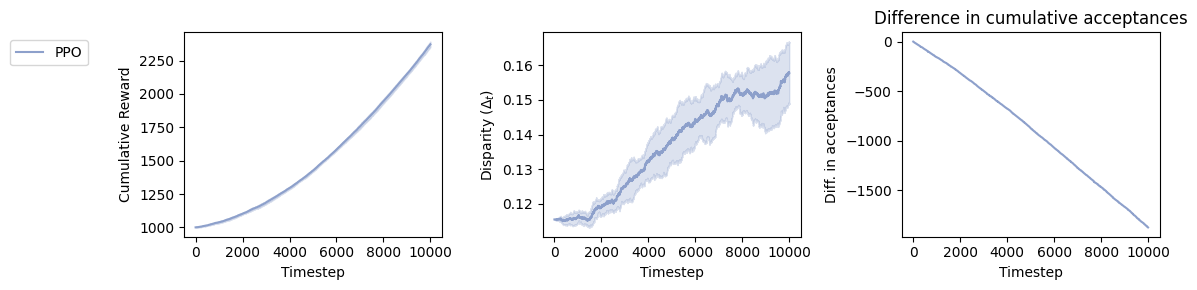

In [14]:
def legend_func(alg_name):
    if "sellf" in alg_name:
        return "Sellf"
    if "ppo" in alg_name:
        return "PPO"
    if "pocar" in alg_name:
        return "POCAR"


def color_func(alg_name):
    if "sellf" in alg_name:
        return "#e78ac3"
    if "ppo" in alg_name:
        return "#8da0cb"
    if "pocar" in alg_name:
        return "#fc8d62"


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
for alg, df in zip(selected_algs, df_list):
    axs[0].plot(
        df.index, df["resource"]["mean"], label=legend_func(alg), color=color_func(alg)
    )
    axs[0].fill_between(
        df.index,
        df["resource"]["mean"] - df["resource"]["std"],
        df["resource"]["mean"] + df["resource"]["std"],
        alpha=0.3,
        color=color_func(alg),
    )

    axs[1].plot(
        df.index, df["delta"]["mean"], label=legend_func(alg), color=color_func(alg)
    )
    axs[1].fill_between(
        df.index,
        df["delta"]["mean"] - df["delta"]["std"],
        df["delta"]["mean"] + df["delta"]["std"],
        alpha=0.3,
        color=color_func(alg),
    )

    # calculate the difference in acceptance
    diff_accept = df["n_accept_g0"]["mean"] - df["n_accept_g1"]["mean"]
    axs[2].plot(
        df.index,
        diff_accept,
        label=legend_func(alg),
        color=color_func(alg),
    )


for i in range(3):
    axs[i].set_xlabel("Timestep")

axs[0].set_ylabel("Cumulative Reward")
axs[1].set_ylabel("Disparity ($\Delta_t$)")
axs[2].set_ylabel("Diff. in acceptances")
axs[2].set_title("Difference in cumulative acceptances")


# place legend outside the left plot
axs[0].legend(loc="center left", bbox_to_anchor=(-0.7, 0.9))
plt.tight_layout()
plt.savefig("figures/enem_quali.pdf", bbox_inches='tight')
plt.show()


# ENEM with qualification

In [3]:
env_name = "enem"
mu_type = "qualification"

## Comparative

In [12]:
alg_names = []
for i in range(5):
    alg_names.append(f"simple_agent_exp{i}")
results = summarize_hyperparam(env_name, mu_type, alg_names)
results

,alg,alg_simplified,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1
0,simple_agent_exp0,simple,0.114440,0.002035,0.114440,0.002035,937.65,10.556857,0.501766,0.497113
1,simple_agent_exp1,simple,0.112819,0.002923,0.112819,0.002923,924.80,9.589346,1.000000,1.000000
2,simple_agent_exp2,simple,0.115686,0.001445,0.115686,0.001445,1000.00,0.000000,0.000000,0.000000
3,simple_agent_exp3,simple,0.124852,0.002143,0.124852,0.002143,1010.70,9.790018,0.000000,1.000000
4,simple_agent_exp4,simple,0.103653,0.002692,0.103653,0.002692,914.10,8.540101,1.000000,0.000000


In [5]:
alg_names = ["ppo_"]
for beta in [0.5, 1, 2, 5]:
    alg_names.append(f"sellf_hard_beta_1={beta} beta_2={beta}")
    alg_names.append(f"pocar_beta_1={beta} beta_2={beta}")
results = summarize_hyperparam(env_name, mu_type, alg_names)
results.sort_values("delta").groupby("alg_simplified").first()

,alg,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1
alg_simplified,,,,,,,,,
pocar,pocar_beta_1=5 beta_2=5,0.131486,0.004524,0.085547,0.011211,2184.95,25.390779,0.578529,0.762115
ppo,ppo_,0.136096,0.003452,0.136096,0.003452,2372.50,20.156333,0.327810,0.551864
sellf,sellf_hard_beta_1=5 beta_2=5,0.135416,0.004768,0.140760,0.010988,2098.90,24.834787,0.379470,0.613560


In [6]:
selected_algs = (
    results.sort_values("delta").groupby("alg_simplified").first()["alg"].tolist()
)

In [13]:
selected_algs = alg_names

In [34]:

def percentile(n):
    def percentile_(x):
        return x.quantile(n)
    percentile_.__name__ = 'percentile_{:02.0f}'.format(n*100)
    return percentile_


df_list = [
    pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv")
    for alg in selected_algs
]
for i in range(len(df_list)):
    # create column with number of acceptions for each group
    df_list[i]["accept_g0"] = df_list[i]["action"] * (df_list[i]["group_id"] == 0)
    df_list[i]["accept_g1"] = df_list[i]["action"] * (df_list[i]["group_id"] == 1)
    
    # for each ep, compute cumulative sum of accept_g0 and accept_g1
    df_list[i]["n_accept_g0"] = df_list[i].groupby("ep")["accept_g0"].cumsum()
    df_list[i]["n_accept_g1"] = df_list[i].groupby("ep")["accept_g1"].cumsum()

    df_list[i] = (
        df_list[i]
        .groupby("t")
        .agg(
            {
                "resource": ["mean", "std"],
                "delta": ["mean", percentile(0.1), percentile(0.9)],
                "n_accept_g0": ["mean", "std"],
                "n_accept_g1": ["mean", "std"],
            }
        )
    )

In [35]:
df_list[0]

resource                delta                             n_accept_g0  \
         mean        std      mean percentile_10 percentile_90        mean   
t                                                                            
0      999.90   0.316228  0.105665      0.105665      0.105665         0.3   
1      999.95   0.497214  0.105665      0.105665      0.105665         0.4   
2      999.95   0.761942  0.105665      0.105665      0.105665         0.6   
3      999.80   0.918937  0.105665      0.105665      0.105665         0.9   
4      999.50   0.881917  0.105665      0.105665      0.105665         1.2   
...       ...        ...       ...           ...           ...         ...   
2043   902.25  12.983430  0.104730      0.103431      0.105540       418.5   
2044   902.45  13.267441  0.104747      0.103431      0.105540       418.5   
2045   902.30  13.256445  0.104764      0.103431      0.105540       418.9   
2046   902.30  13.302464  0.104764      0.103431      0.105540       419.1   
2047   902.20  13.283657  0.104764      0.103431      0.105540       419.2   

                n_accept_g1             
            std        mean        std  
t                                       
0      0.483046         0.1   0.316228  
1      0.516398         0.5   0.707107  
2      0.516398         0.7   0.948683  
3      0.567646         0.9   1.100505  
4      0.632456         1.2   1.032796  
...         ...         ...        ...  
2043  12.483322       600.6  16.419501  
2044  12.483322       601.2  16.524729  
2045  12.617889       601.3  16.432015  
2046  12.617889       601.5  16.534476  
2047  12.813188       602.0  16.586474  

[2048 rows x 9 columns]

In [ ]:

df_list = [
    pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv")
    for alg in selected_algs
]
for i in range(len(df_list)):
    # create column with number of acceptions for each group
    df_list[i]["accept_g0"] = df_list[i]["action"] * (df_list[i]["group_id"] == 0)
    df_list[i]["accept_g1"] = df_list[i]["action"] * (df_list[i]["group_id"] == 1)
    
    # for each ep, compute cumulative sum of accept_g0 and accept_g1
    df_list[i]["n_accept_g0"] = df_list[i].groupby("ep")["accept_g0"].cumsum()
    df_list[i]["n_accept_g1"] = df_list[i].groupby("ep")["accept_g1"].cumsum()

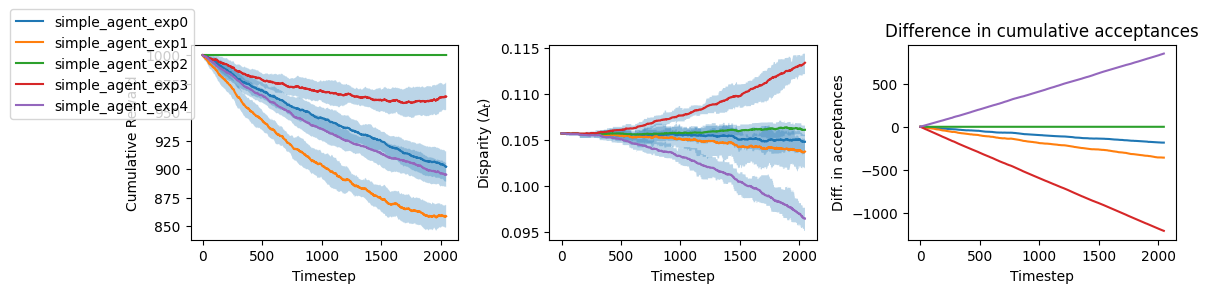

In [36]:
def legend_func(alg_name):
    if "sellf" in alg_name:
        return "Sellf"
    if "ppo" in alg_name:
        return "PPO"
    if "pocar" in alg_name:
        return "POCAR"
    return alg_name


def color_func(alg_name):
    if "sellf" in alg_name:
        return "#e78ac3"
    if "ppo" in alg_name:
        return "#8da0cb"
    if "pocar" in alg_name:
        return "#fc8d62"


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
for alg, df in zip(selected_algs, df_list):
    axs[0].plot(
        df.index, df["resource"]["mean"], label=legend_func(alg), color=color_func(alg)
    )
    axs[0].fill_between(
        df.index,
        df["resource"]["mean"] - df["resource"]["std"],
        df["resource"]["mean"] + df["resource"]["std"],
        alpha=0.3,
        color=color_func(alg),
    )

    axs[1].plot(
        df.index, df["delta"]["mean"], label=legend_func(alg), color=color_func(alg)
    )
    axs[1].fill_between(
        df.index,
        #df["delta"]["mean"] - df["delta"]["std"],
        #df["delta"]["mean"] + df["delta"]["std"],
        df["delta"]["percentile_10"],
        df["delta"]["percentile_90"],
        alpha=0.3,
        color=color_func(alg),
    )

    # calculate the difference in acceptance
    diff_accept = df["n_accept_g0"]["mean"] - df["n_accept_g1"]["mean"]
    axs[2].plot(
        df.index,
        diff_accept,
        label=legend_func(alg),
        color=color_func(alg),
    )


for i in range(3):
    axs[i].set_xlabel("Timestep")

axs[0].set_ylabel("Cumulative Reward")
axs[1].set_ylabel("Disparity ($\Delta_t$)")
axs[2].set_ylabel("Diff. in acceptances")
axs[2].set_title("Difference in cumulative acceptances")


# place legend outside the left plot
axs[0].legend(loc="center left", bbox_to_anchor=(-0.7, 0.9))
plt.tight_layout()
#plt.savefig("figures/fico_tpr.pdf", bbox_inches='tight')
plt.show()
